In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Detecting encoding of dataset

In [2]:
import chardet
path="/kaggle/input/datasets/vivek468/superstore-dataset-final/Sample - Superstore.csv"
with open(path, "rb") as f:
    result=chardet.detect(f.read())
print(result)

{'encoding': 'Windows-1252', 'confidence': 0.73, 'language': ''}


In [3]:
df=pd.read_csv("/kaggle/input/datasets/vivek468/superstore-dataset-final/Sample - Superstore.csv", encoding="cp1252")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [5]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [6]:
df.duplicated().sum()

np.int64(0)

> The dataset has no duplicate rows, no missing values

## correcting date format and adding some features

In [7]:
df["Order Date"]=pd.to_datetime(df["Order Date"])
df["Ship Date"]=pd.to_datetime(df["Ship Date"])
df["Order Month"]=df["Order Date"].dt.month
df["Ship Month"]=df["Ship Date"].dt.month
df["Order Year"]=df["Order Date"].dt.year
df["Ship Year"]=df["Ship Date"].dt.year

In [8]:
len(df[df["Order Date"].dt.month == 1].index)

381

In [9]:
overall_month_sales=pd.DataFrame(columns=["Month", "Number of sales", "Total sales", "Total profit"])

In [10]:
overall_month_sales= df.groupby("Order Month", sort=True).agg(
    Number_of_sales=("Sales","count"),
    Total_sales=("Sales","sum"),
    Total_profit=("Profit","sum")
).reset_index()
overall_month_sales.rename(columns={"Order Month": "Month"}, inplace=True)
overall_month_sales["Month"]=pd.to_datetime(overall_month_sales["Month"],format="%m").dt.month_name()
overall_month_sales

,Month,Number_of_sales,Total_sales,Total_profit
0,January,381,94924.8356,9134.4461
1,February,300,59751.2514,10294.6107
2,March,696,205005.4888,28594.6872
3,April,668,137762.1286,11587.4363
4,May,735,155028.8117,22411.3078
5,June,717,152718.6793,21285.7954
6,July,710,147238.0970,13832.6648
7,August,706,159044.0630,21776.9384
8,September,1383,307649.9457,36857.4753
9,October,819,200322.9847,31784.0413


## Finding KPI's

In [11]:
total_sale=overall_month_sales["Total_sales"].sum()
total_profit=overall_month_sales["Total_profit"].sum()
total_uni_orders=df["Order ID"].nunique()
avg_order_val=total_sale/total_uni_orders
profit_margin=(total_profit/total_sale)*100

In [27]:
total_sale

np.float64(2297200.8603)

### Finding:
- Best-performing and
- Loss-making

In [12]:
cat_sales=df.groupby("Category")[["Sales","Profit"]].sum().reset_index()
sub_cat_sales=df.groupby("Sub-Category")[["Sales","Profit"]].sum().reset_index()
region_sales=df.groupby("Region")[["Sales","Profit"]].sum().reset_index()
seg_sales=df.groupby("Segment")[["Sales","Profit"]].sum().reset_index()

In [58]:
city_sales = df.groupby('City')[['Sales', 'Profit']].sum().sort_values(by='Profit', ascending=False)
city_sales.head()

,Sales,Profit
City,,
New York City,256368.161,62036.9837
Los Angeles,175851.341,30440.7579
Seattle,119540.742,29156.0967
San Francisco,112669.092,17507.3854
Detroit,42446.944,13181.7908


In [29]:
sub_cat_sales.head()

,Sub-Category,Sales,Profit
0,Accessories,167380.3180,41936.6357
1,Appliances,107532.1610,18138.0054
2,Art,27118.7920,6527.7870
3,Binders,203412.7330,30221.7633
4,Bookcases,114879.9963,-3472.5560


In [14]:
region_sales

,Region,Sales,Profit
0,Central,501239.8908,39706.3625
1,East,678781.2400,91522.7800
2,South,391721.9050,46749.4303
3,West,725457.8245,108418.4489


### Adding Profit Margin in Category (in percentage format)

In [32]:
cat_sales['Profit_Margin']=(cat_sales['Profit'] / cat_sales['Sales']) * 100
cat_sales

,Category,Sales,Profit,Profit_Margin
0,Furniture,741999.7953,18451.2728,2.486695
1,Office Supplies,719047.0320,122490.8008,17.035158
2,Technology,836154.0330,145454.9481,17.395712


### Which months consistently perform best?

In [28]:
seasonality = df.groupby('Order Month')['Sales'].mean()
seasonality

Order Month
1     249.146550
2     199.170838
3     294.548116
4     206.230731
5     210.923553
6     212.996763
7     207.377601
8     225.274877
9     222.451154
10    244.594609
11    239.606438
12    231.032318
Name: Sales, dtype: float64

### Correlation between Sales, Profit, and Discount

In [15]:
df[['Sales','Profit','Discount']].corr()

,Sales,Profit,Discount
Sales,1.000000,0.479064,-0.028190
Profit,0.479064,1.000000,-0.219487
Discount,-0.028190,-0.219487,1.000000


### Finding loss-making products and subcategories

In [73]:
loss_products = df[df['Profit'] < 0]
loss_by_subcat = loss_products.groupby('Sub-Category')['Profit'].sum()
loss_by_subcat

Sub-Category
Accessories     -930.6265
Appliances     -8629.6412
Binders       -38510.4964
Bookcases     -12152.2060
Chairs         -9880.8413
Fasteners        -33.1952
Furnishings    -6490.9134
Machines      -30118.6682
Phones         -7530.6235
Storage        -6426.3038
Supplies       -3015.6219
Tables        -32412.1483
Name: Profit, dtype: float64

### Best performing

In [17]:
max_cat_sales=cat_sales.max()
max_sub_sales=sub_cat_sales.max()
max_reg_sales=region_sales.max()
max_seg_sales=seg_sales.max()
best_sales={
    "Best category": [max_cat_sales["Category"], max_cat_sales["Sales"], max_cat_sales["Profit"]],
    "Best Sub category": [max_sub_sales["Sub-Category"], max_sub_sales["Sales"], max_sub_sales["Profit"]],
    "Best Region": [max_reg_sales["Region"], max_reg_sales["Sales"], max_reg_sales["Profit"]],
    "Best Segment": [max_seg_sales["Segment"],max_seg_sales["Sales"], max_seg_sales["Profit"]]
}
best_sales=pd.DataFrame(best_sales)
best_sales.index=["Name","Sales","Profit"]
best_sales

,Best category,Best Sub category,Best Region,Best Segment
Name,Technology,Tables,West,Home Office
Sales,836154.033,330007.054,725457.8245,1161401.345
Profit,145454.9481,55617.8249,108418.4489,134119.2092


In [18]:
max_cat_sales=cat_sales.max()
max_cat_sales["Category"]

'Technology'

### YOY (Year-Over-Year) Growth

In [19]:
yearly_sales=df.groupby('Order Year')[['Sales', 'Profit']].sum().reset_index()
yearly_sales

,Order Year,Sales,Profit
0,2014,484247.4981,49543.9741
1,2015,470532.5090,61618.6037
2,2016,609205.5980,81795.1743
3,2017,733215.2552,93439.2696


- I use a **Weighted average discount** instead of an average discount because
    - Average discount treats all orders equal, irrespective of sales
    - But weighted average discount calculates the average, depending on the order sales, i.e. gives more value to larger sales value.
    </br>Formula: ` weighted_discount = sum(discount * sales) / sum(sales) `

In [20]:
# monthly_sales = df.resample('ME', on='Order Date')[['Sales','Profit','Discount']].sum()
monthly_sales=df.resample('ME', on='Order Date').apply(
    lambda x:pd.Series({
        'Sales': x['Sales'].sum(),
        'Profit': x['Profit'].sum(),
        'Weighted_discount': (x['Sales']*x['Discount']).sum()/x['Sales'].sum()
    })
)
monthly_sales.head()

,Sales,Profit,Weighted_discount
Order Date,,,
2014-01-31,14236.895,2450.1907,0.049024
2014-02-28,4519.892,862.3084,0.042433
2014-03-31,55691.009,498.7299,0.304424
2014-04-30,28295.345,3488.8352,0.107391
2014-05-31,23648.287,2738.7096,0.179056


- adding **Moving Averages** of window 3 and 6

In [65]:
monthly_sales['Sales_MA_3'] = monthly_sales['Sales'].rolling(window=3).mean().fillna(0)
monthly_sales['Sales_MA_6'] = monthly_sales['Sales'].rolling(window=6).mean().fillna(0)
monthly_sales.head()

,Sales,Profit,Weighted_discount,Sales_MA_3,Sales_MA_6
Order Date,,,,,
2014-01-31,14236.895,2450.1907,0.049024,0.000000,0.0
2014-02-28,4519.892,862.3084,0.042433,0.000000,0.0
2014-03-31,55691.009,498.7299,0.304424,24815.932000,0.0
2014-04-30,28295.345,3488.8352,0.107391,29502.082000,0.0
2014-05-31,23648.287,2738.7096,0.179056,35878.213667,0.0


### Regular customers (repeating customers)

In [35]:
repeat_cust= df['Customer ID'].value_counts()
repeat_cust.head()

Customer ID
WB-21850    37
MA-17560    34
JL-15835    34
PP-18955    34
CK-12205    32
Name: count, dtype: int64

### Top 10 customers

In [51]:
top_customers = df.groupby('Customer ID')['Sales'].sum().sort_values(ascending=False).head(10)
top_customers

Customer ID
SM-20320    25043.050
TC-20980    19052.218
RB-19360    15117.339
TA-21385    14595.620
AB-10105    14473.571
KL-16645    14175.229
SC-20095    14142.334
HL-15040    12873.298
SE-20110    12209.438
CC-12370    12129.072
Name: Sales, dtype: float64

### Revenue of each order (one order can have multiple items)

In [68]:
orders = df.groupby('Order ID')[['Sales','Profit']].sum()
orders.head()

,Sales,Profit
Order ID,,
CA-2014-100006,377.970,109.6113
CA-2014-100090,699.192,-19.0890
CA-2014-100293,91.056,31.8696
CA-2014-100328,3.928,1.3257
CA-2014-100363,21.376,7.7192


## Plotting graph

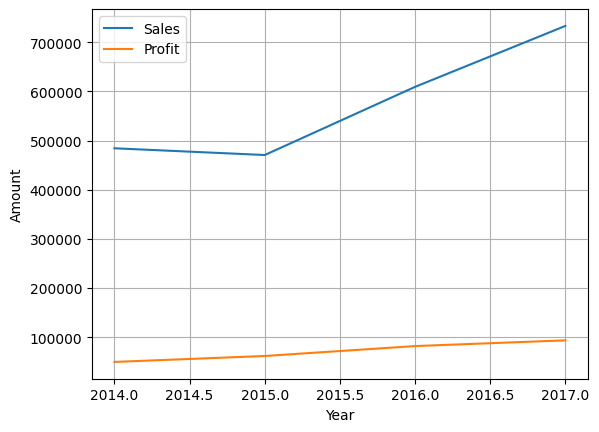

In [21]:
plt.plot(yearly_sales['Order Year'], yearly_sales['Sales'], label='Sales')
plt.plot(yearly_sales['Order Year'], yearly_sales['Profit'], label='Profit')
plt.xlabel('Year')
plt.ylabel('Amount')
plt.legend()
plt.grid()
plt.show()

## Profit vs Sales

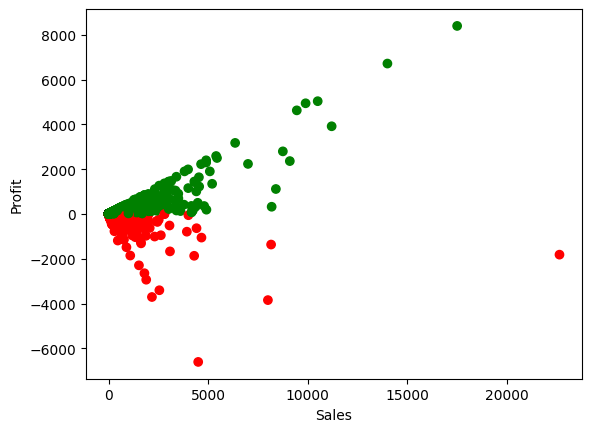

In [69]:
plt.scatter(df["Sales"], df["Profit"], c=colors)
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.show()

### Profit vs Discount
- After discount = 0.3 (30%), the profits are negligible.

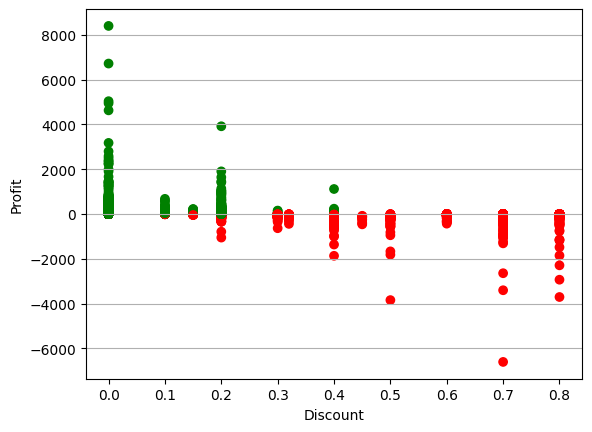

In [23]:
colors = (df["Profit"] > 0).map({True: 'green', False: 'red'}) # pandas Series

plt.scatter(df["Discount"], df["Profit"], c=colors)
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.grid(axis='y')
plt.show()

### Profit vs Weighted Discount

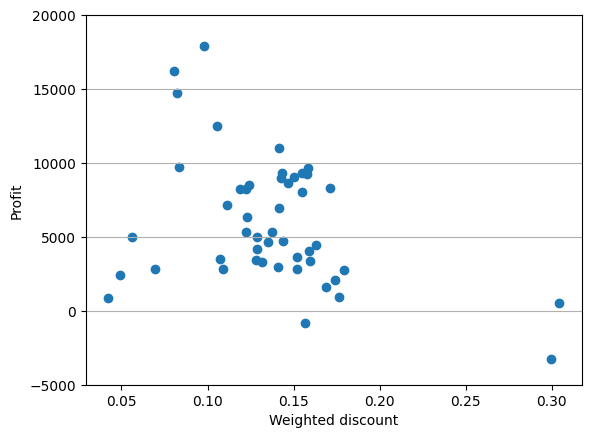

In [24]:
plt.scatter(monthly_sales["Weighted_discount"], monthly_sales["Profit"])
plt.xlabel("Weighted discount")
plt.ylabel("Profit")
plt.ylim(-5000, 20000)
plt.grid(axis='y')
plt.show()

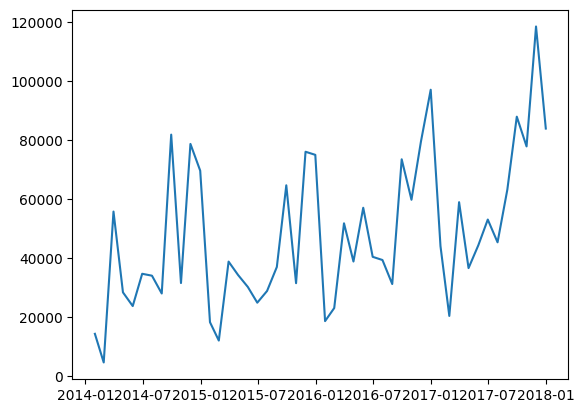

In [25]:
plt.plot(monthly_sales['Sales'])

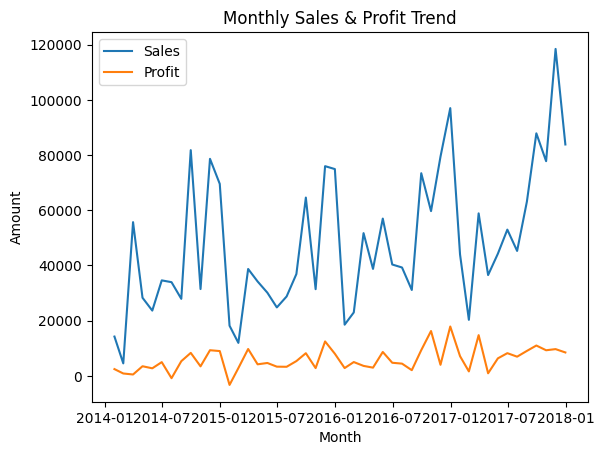

In [26]:
plt.plot(monthly_sales.index, monthly_sales['Sales'], label='Sales')
plt.plot(monthly_sales.index, monthly_sales['Profit'], label='Profit')

plt.title('Monthly Sales & Profit Trend')
plt.xlabel('Month')
plt.ylabel('Amount')
plt.legend()

plt.show()